# Clusterisation des nappes

In [2]:
import sys
import os
import shutil
sys.path.append(os.path.abspath("../../"))

from src.data import *
from src.visualisations import *

In [1]:
dossier_nappe = "../../data/fusion"

dossier_nappe_inertielle = "../../data/clusterisation/inertielle"
dossier_nappe_reactive = "../../data/clusterisation/reactive"

In [3]:
dfs = {fichier:charger_fichier(fichier) for fichier in liste_fichiers(dossier_nappe)}

shutil.rmtree(dossier_nappe_inertielle, ignore_errors=True)
shutil.rmtree(dossier_nappe_reactive, ignore_errors=True)

os.makedirs(dossier_nappe_inertielle, exist_ok=True)
os.makedirs(dossier_nappe_reactive, exist_ok=True)

for nom, df in dfs.items():
    if classifier_nappe_fluctuation(df)["indice_dynamique"]>0.4 :
        df.to_csv(os.path.join(dossier_nappe_reactive, nom.split("\\")[1]), sep=";", index=False)
    else :
        df.to_csv(os.path.join(dossier_nappe_inertielle, nom.split("\\")[1]), sep=";", index=False)

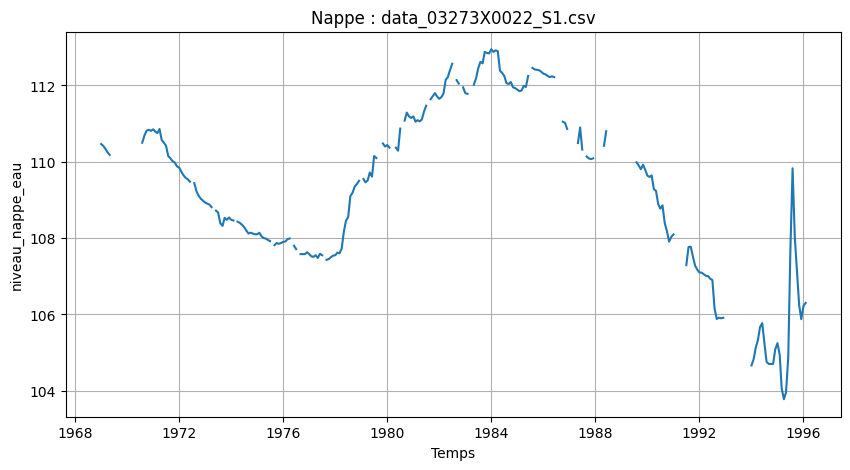

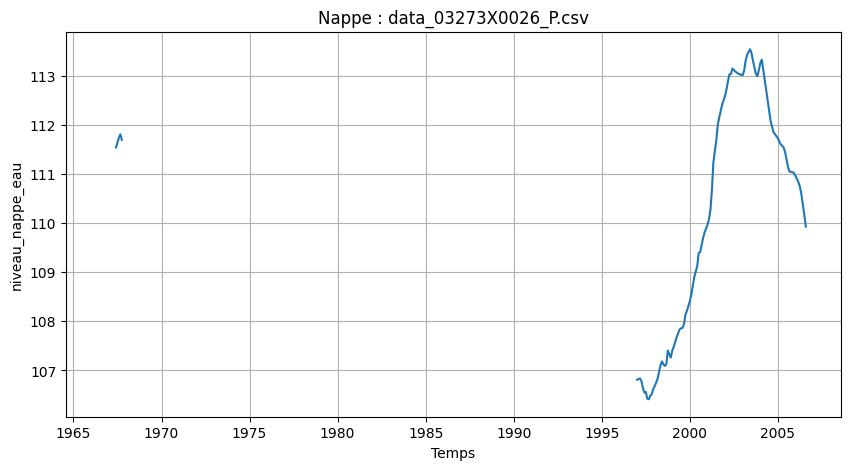

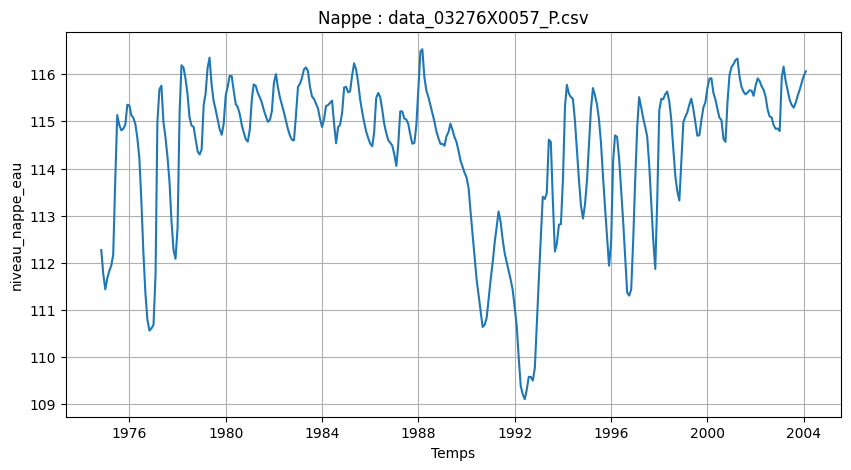

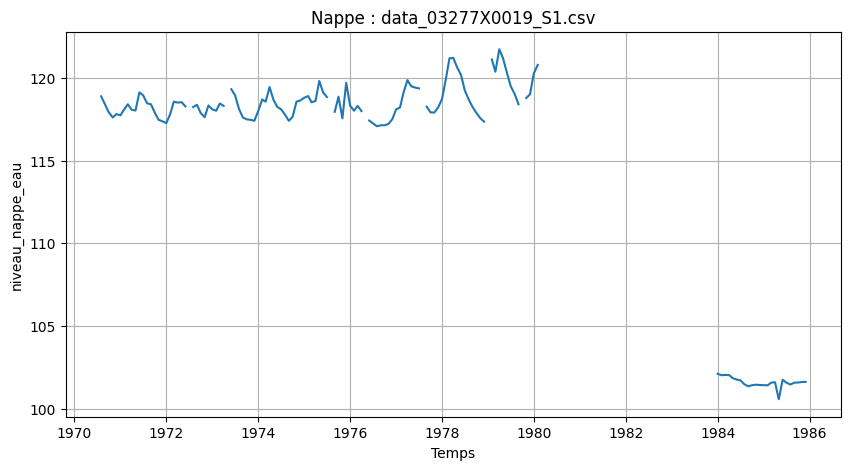

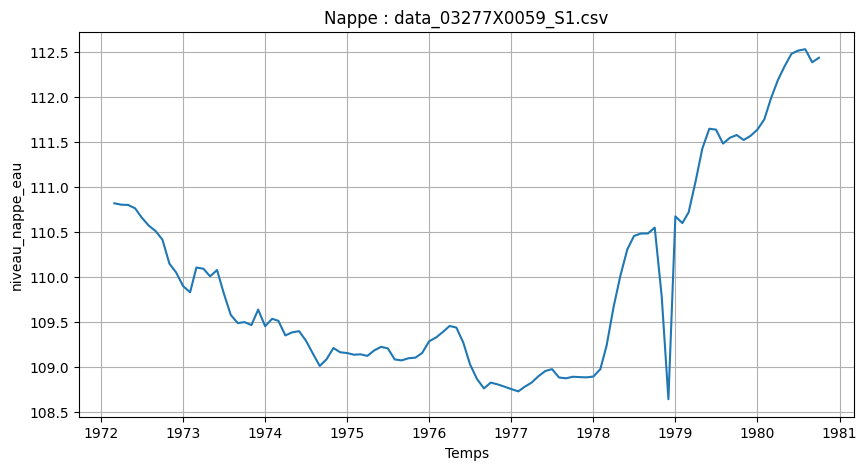

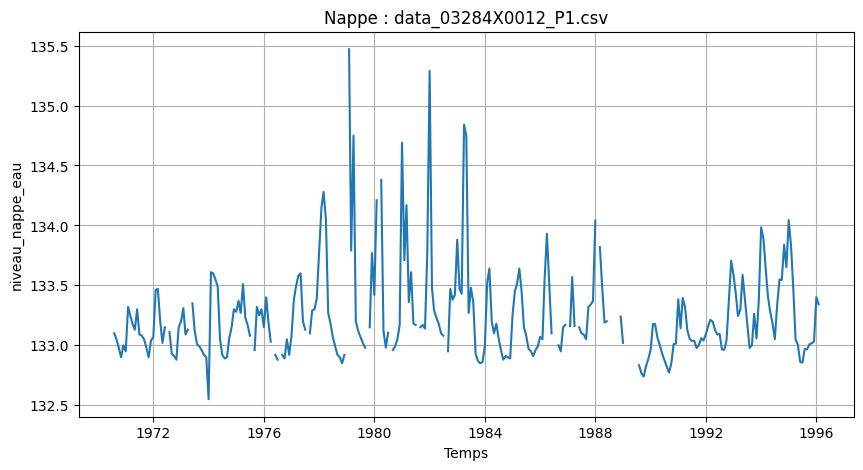

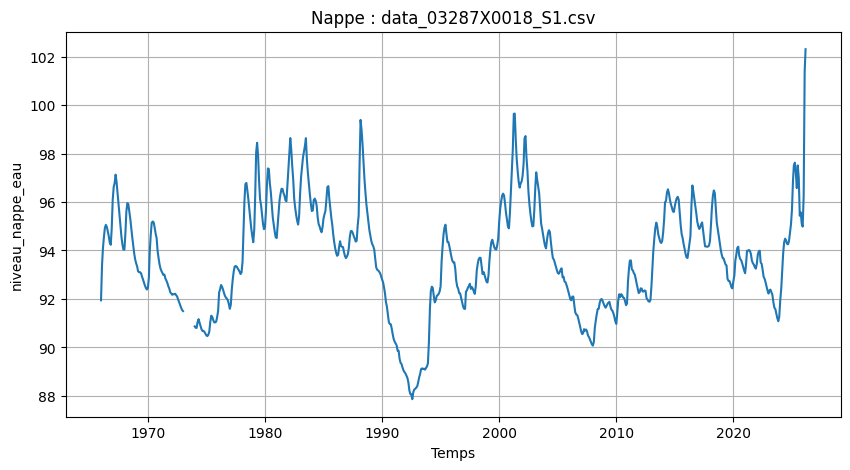

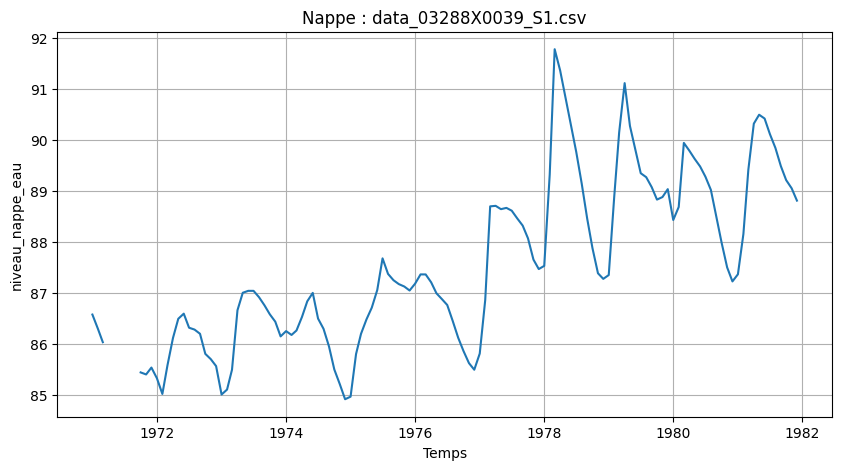

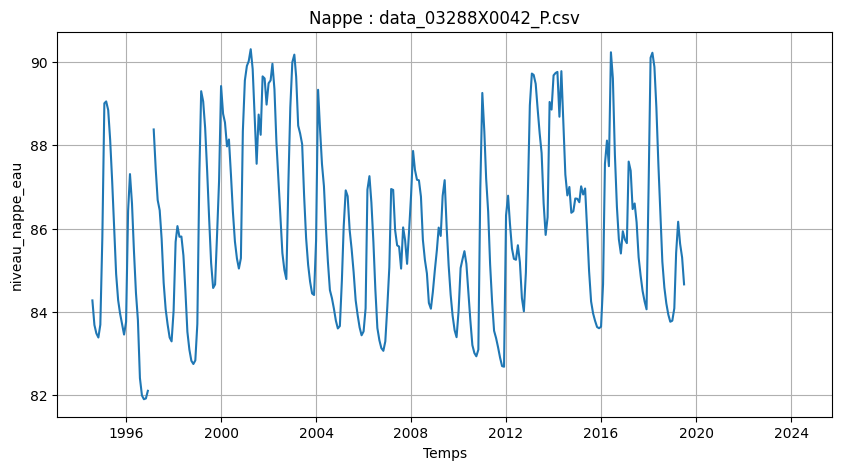

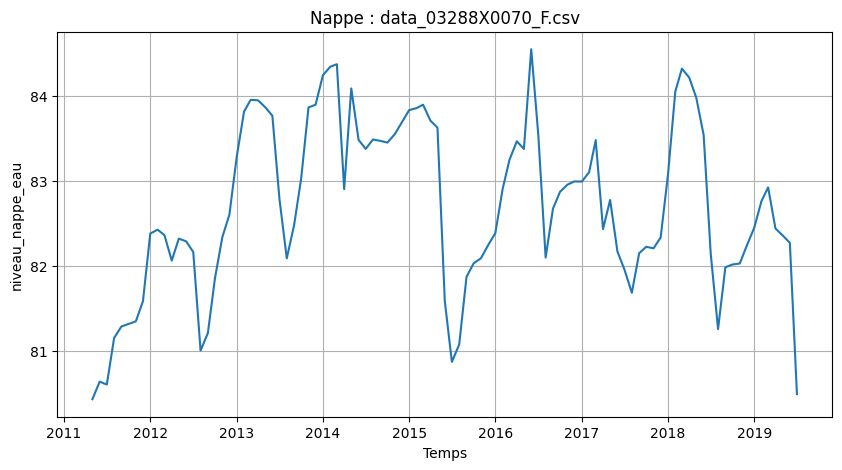

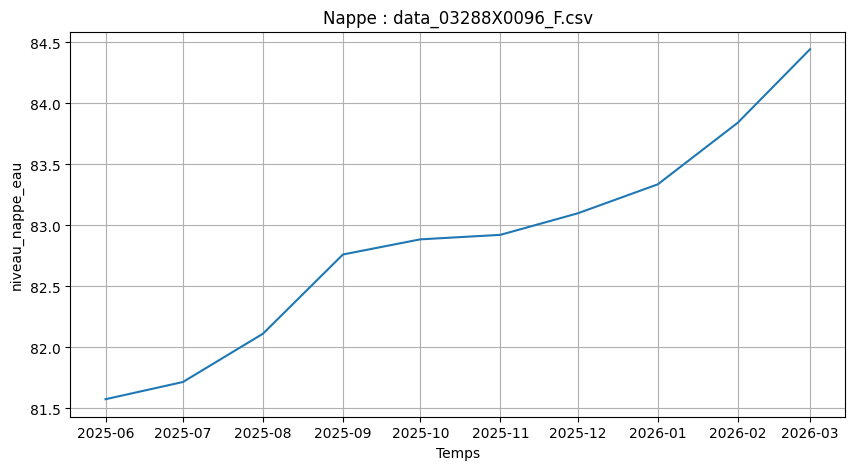

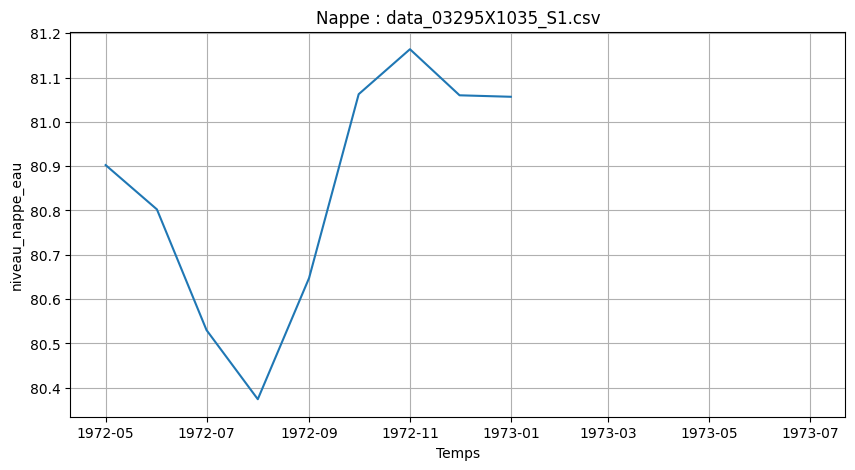

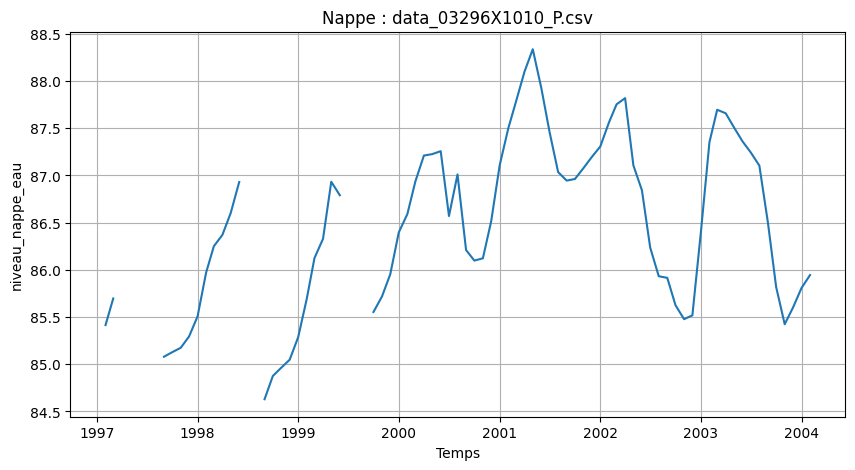

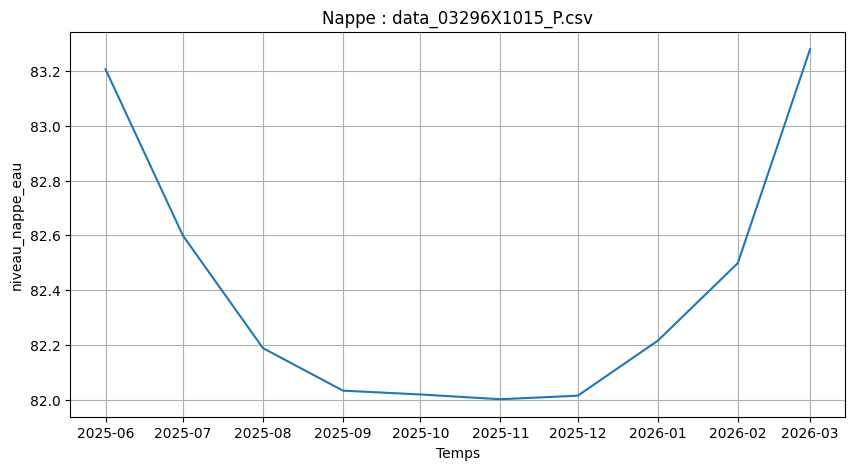

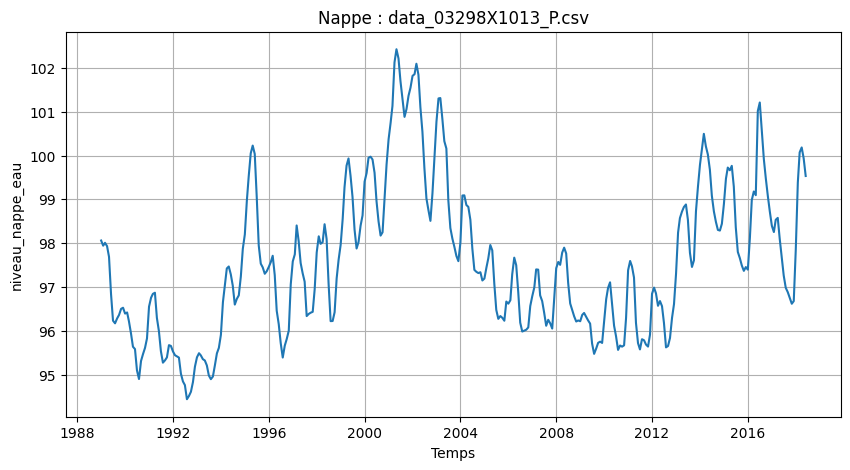

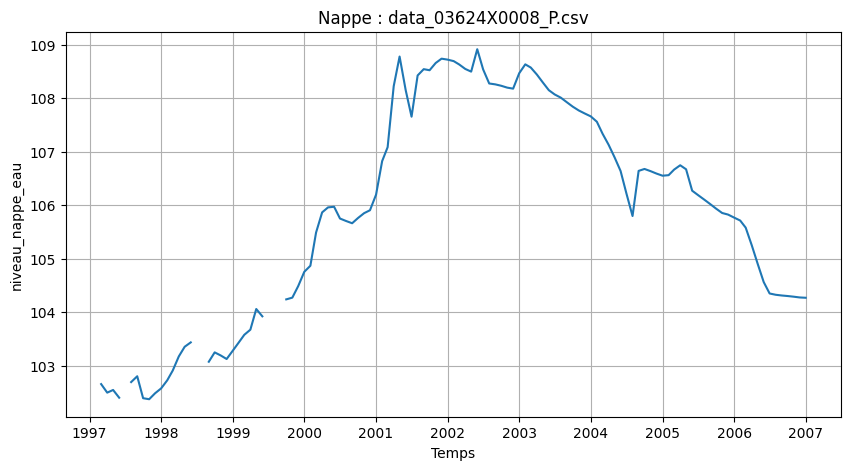

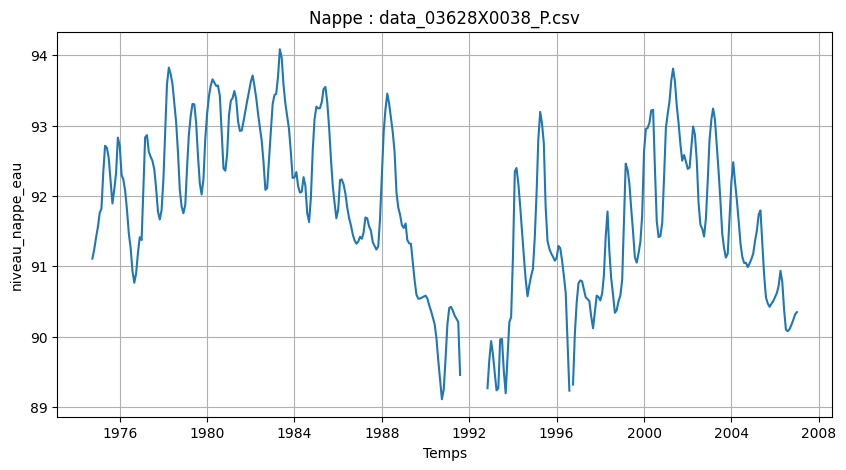

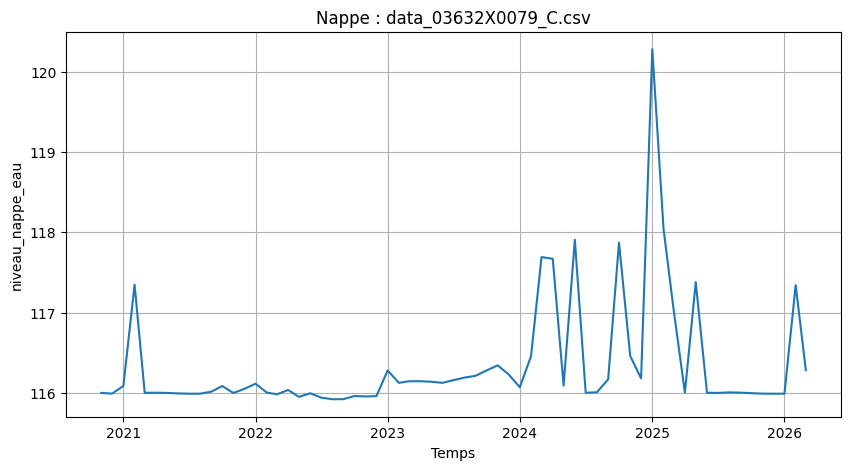

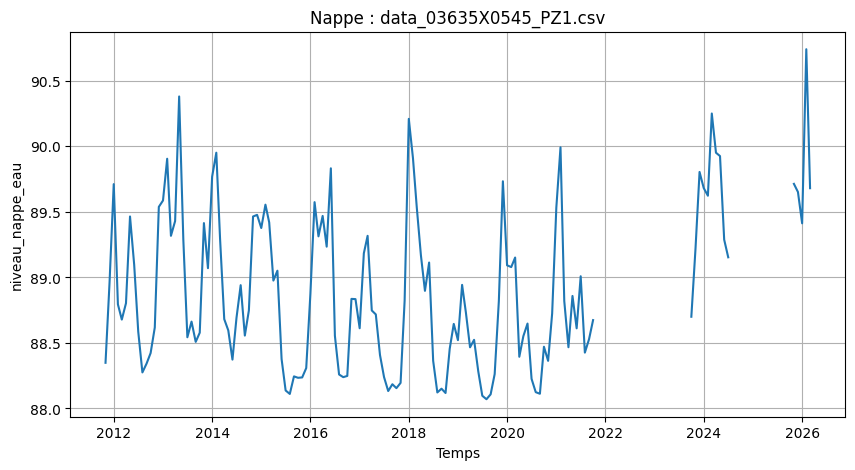

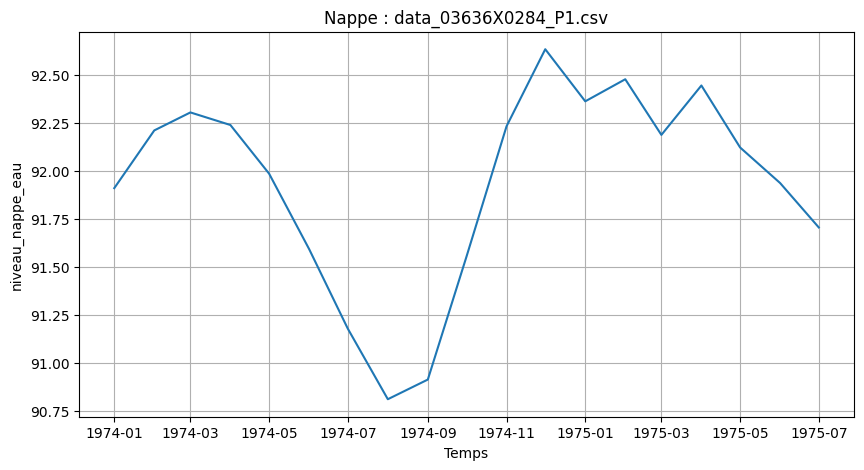

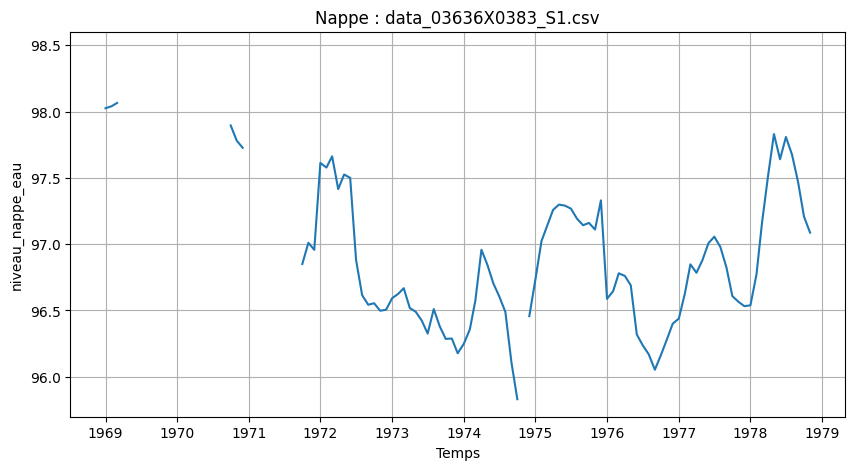

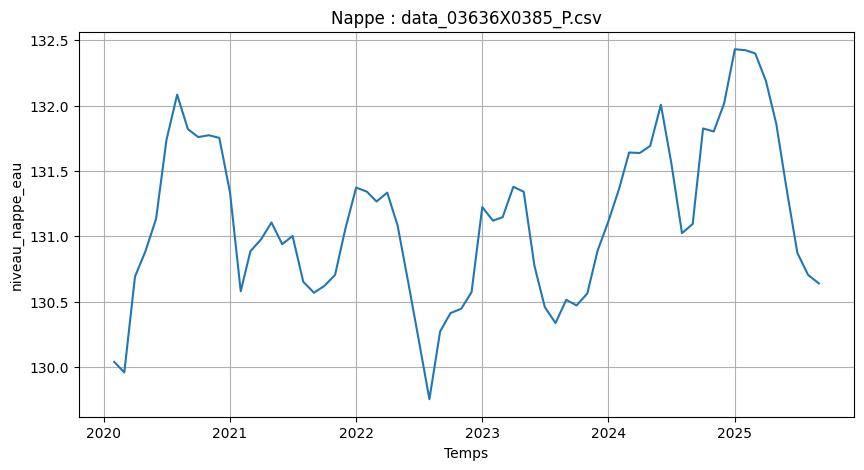

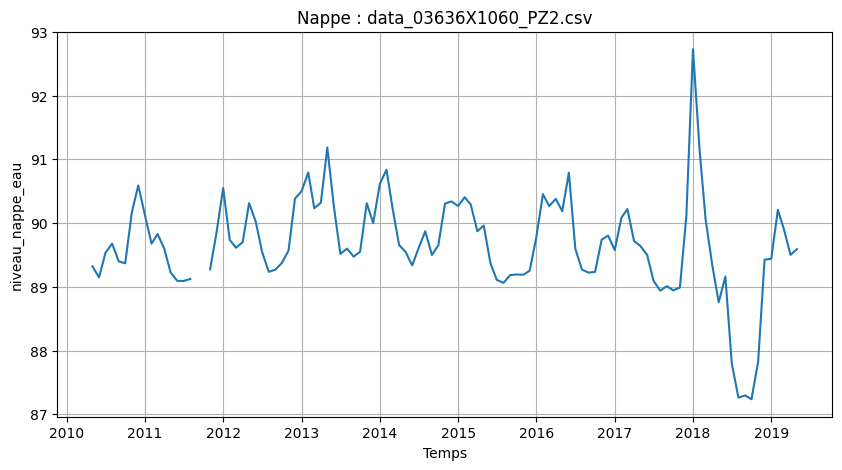

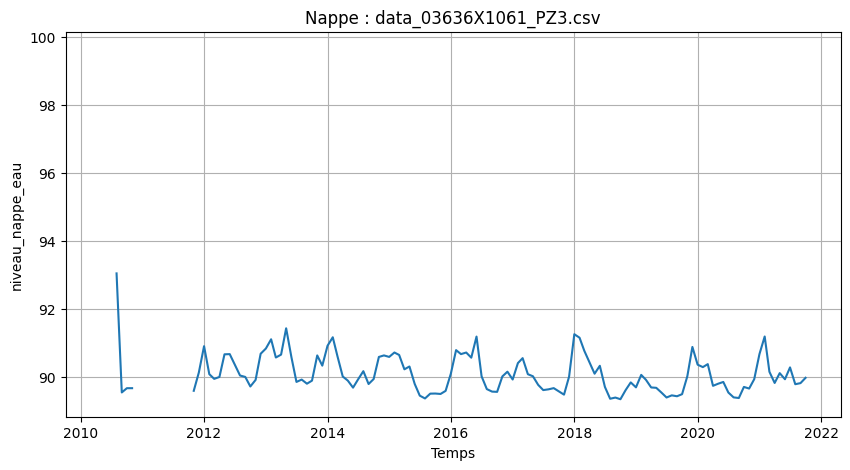

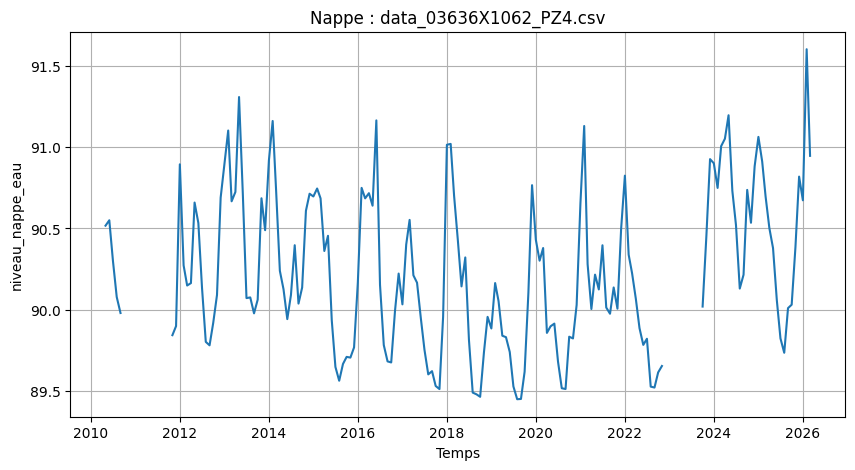

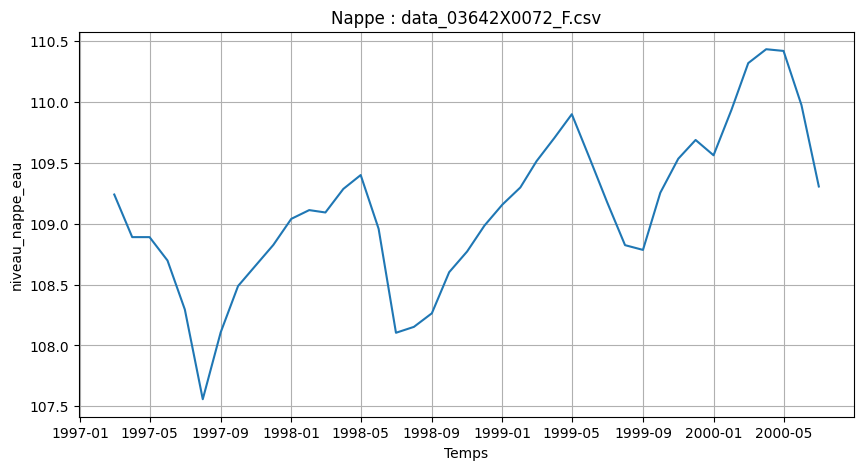

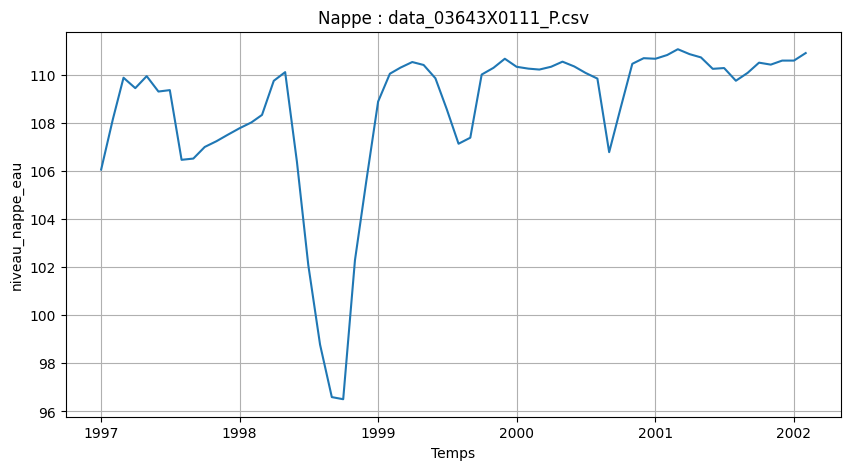

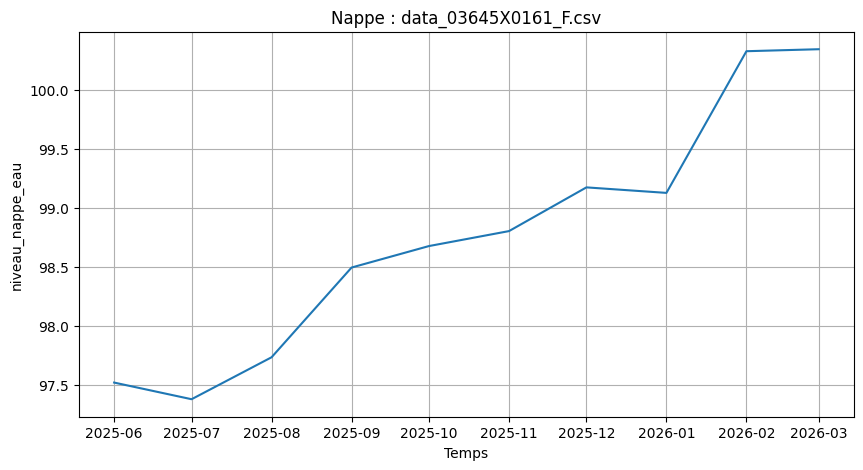

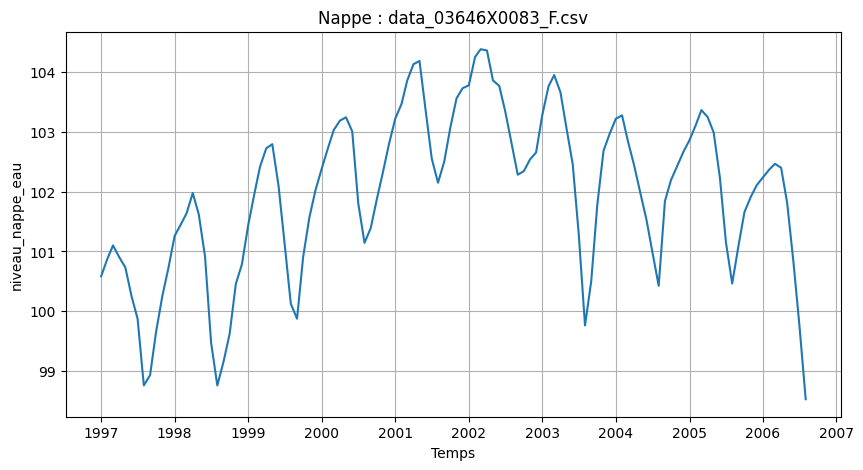

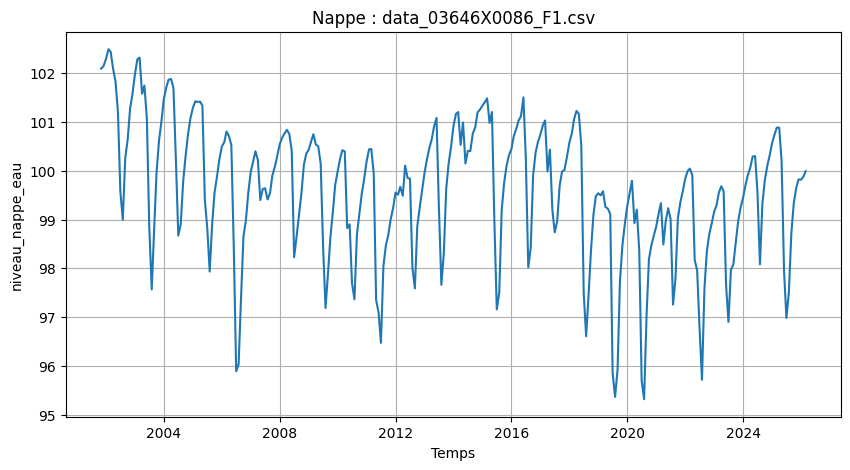

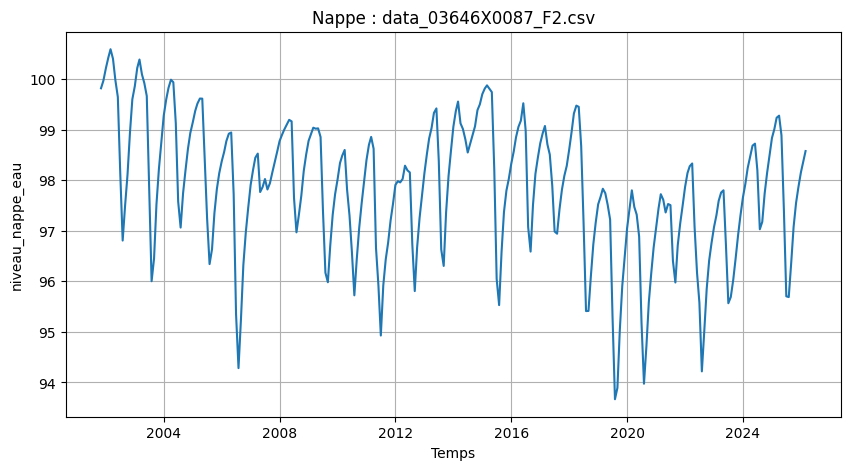

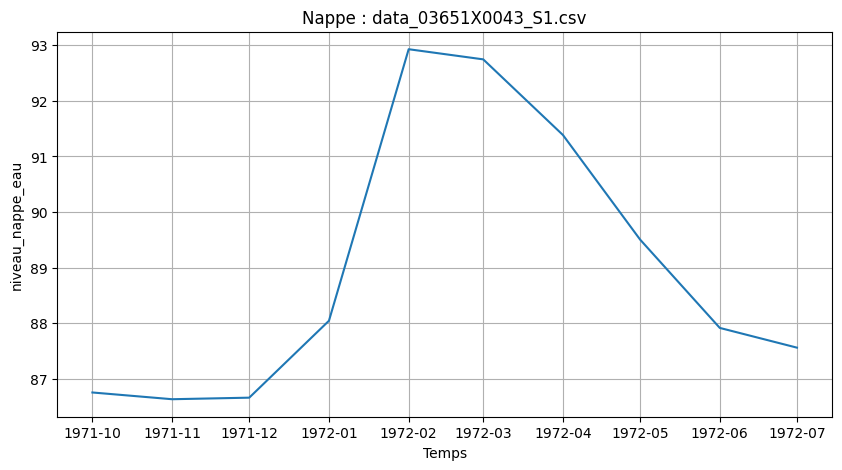

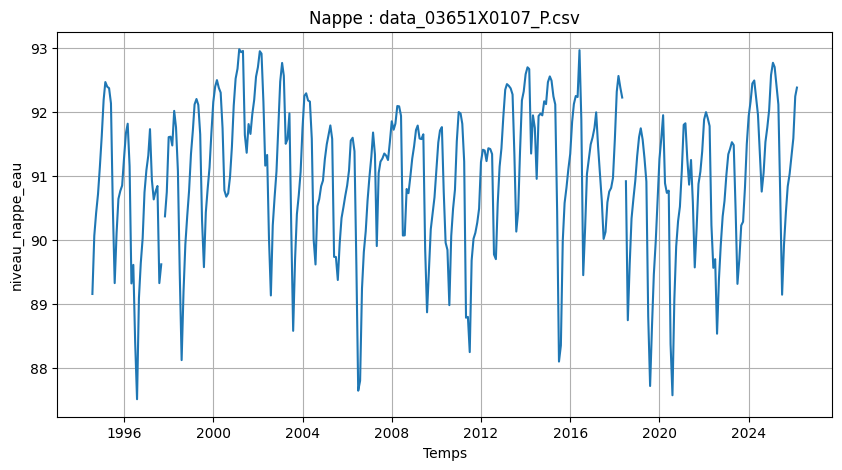

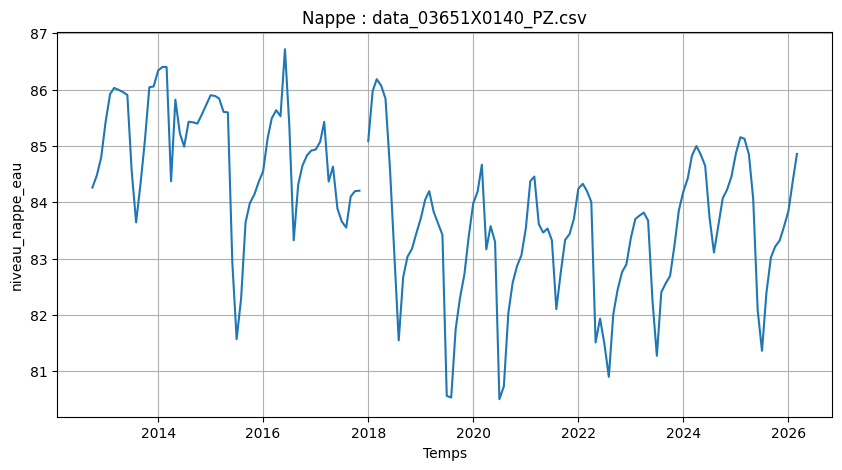

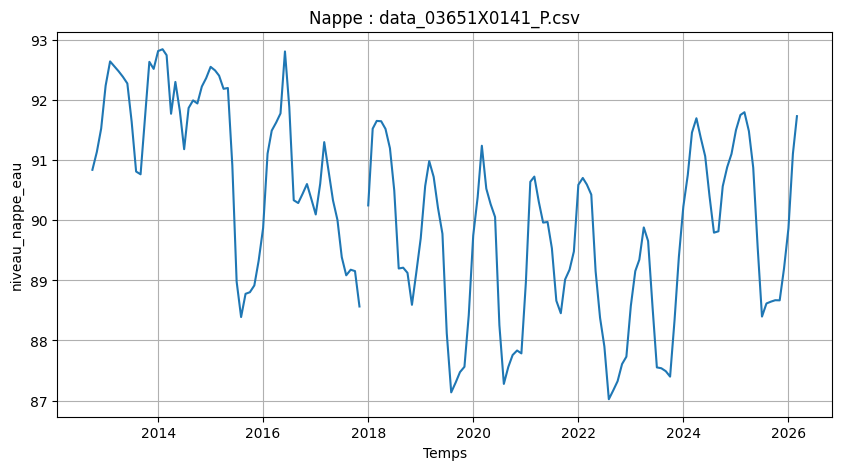

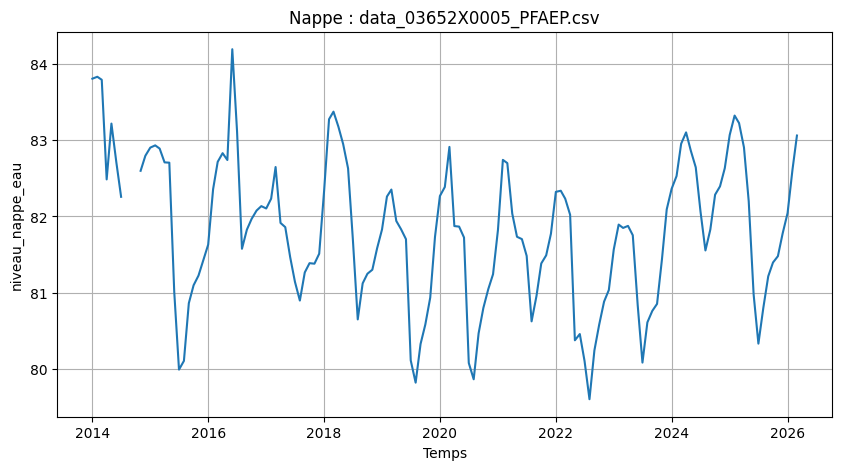

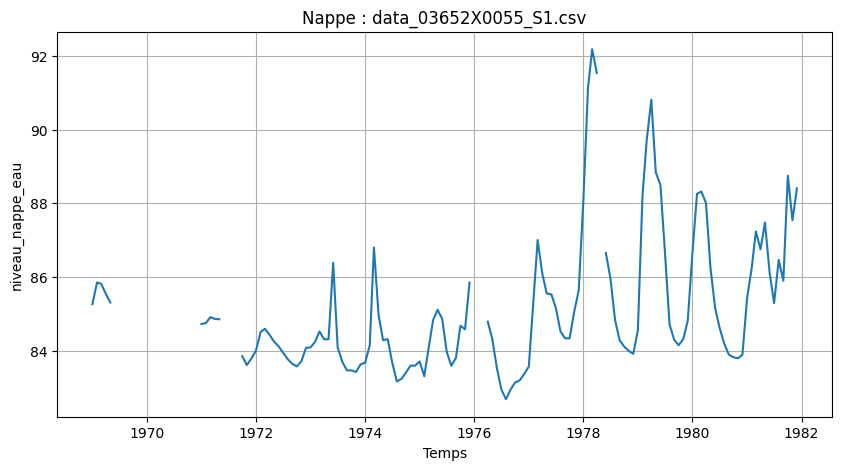

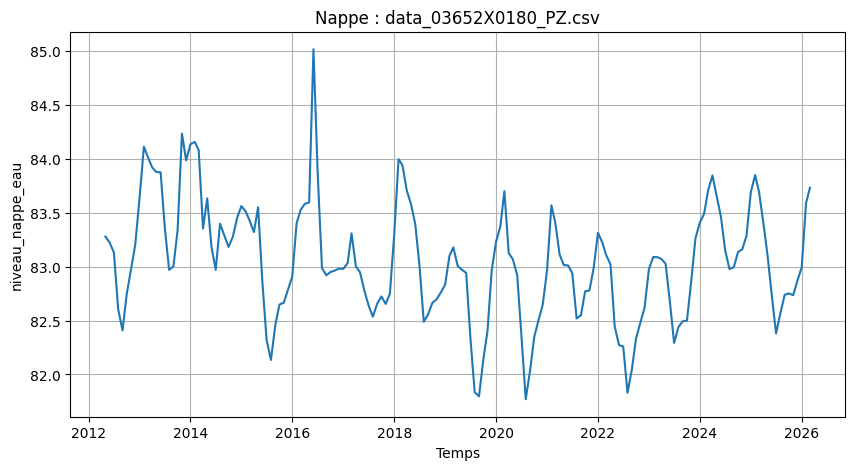

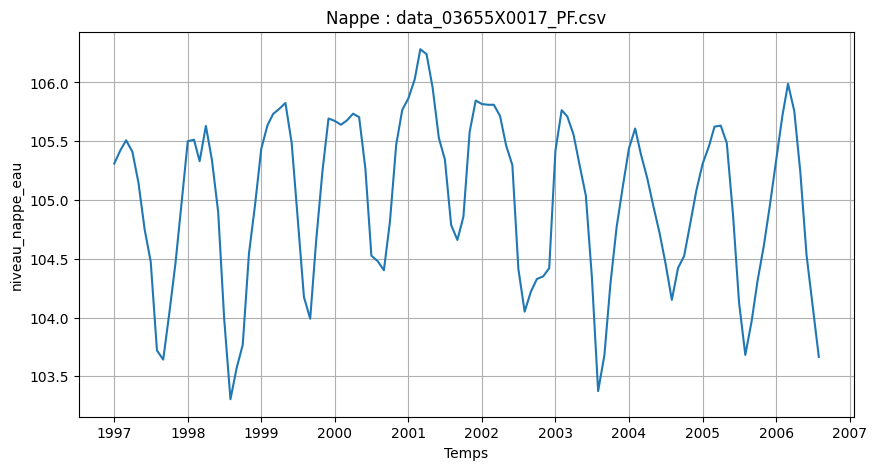

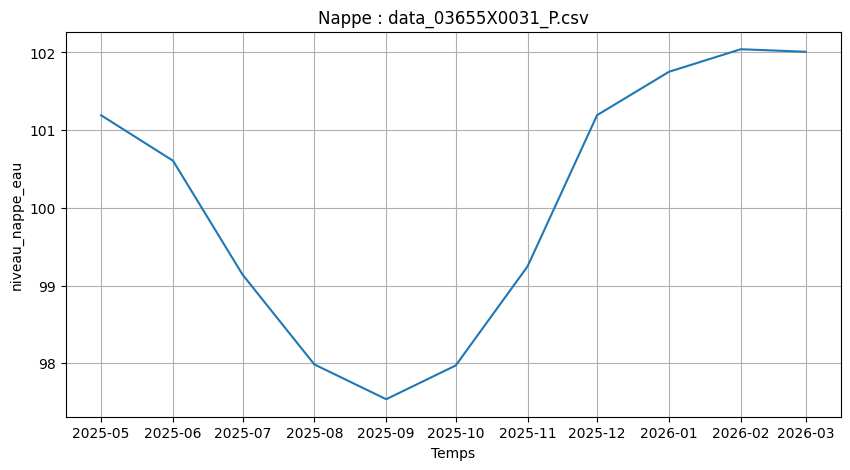

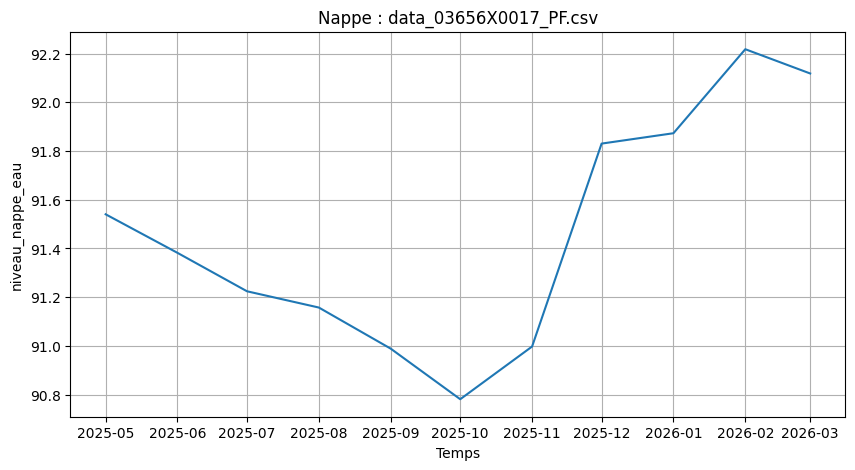

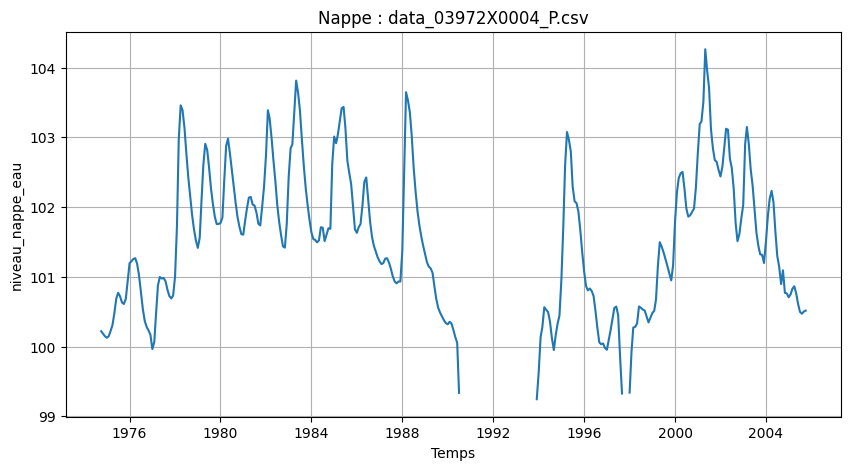

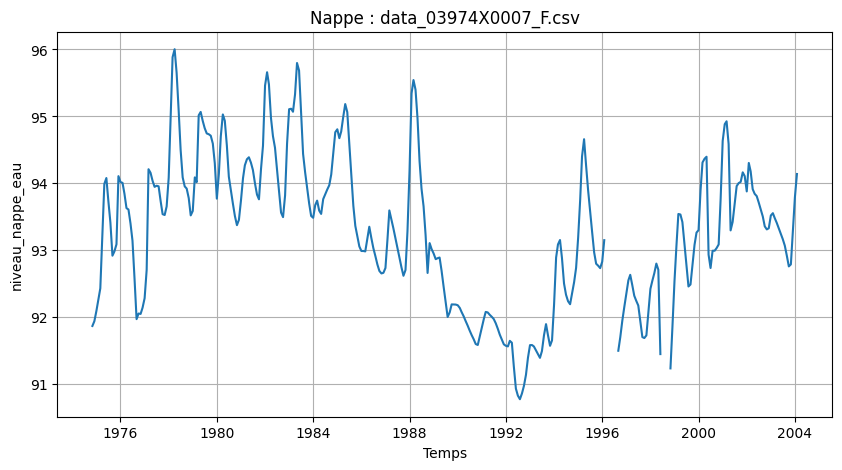

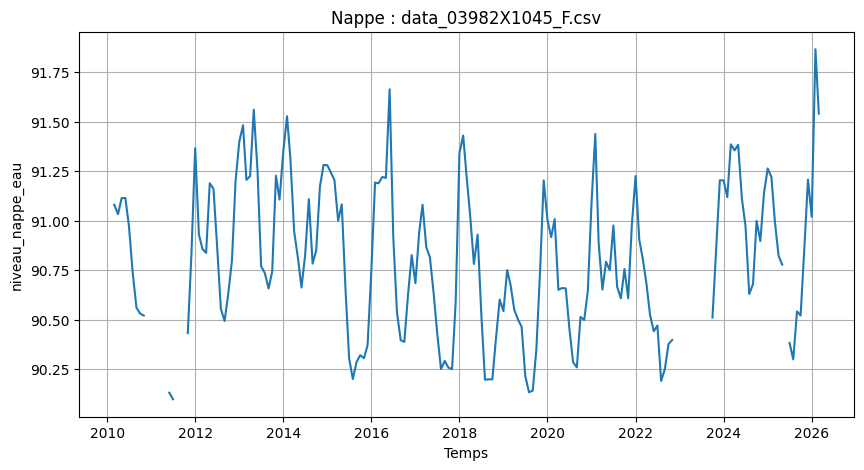

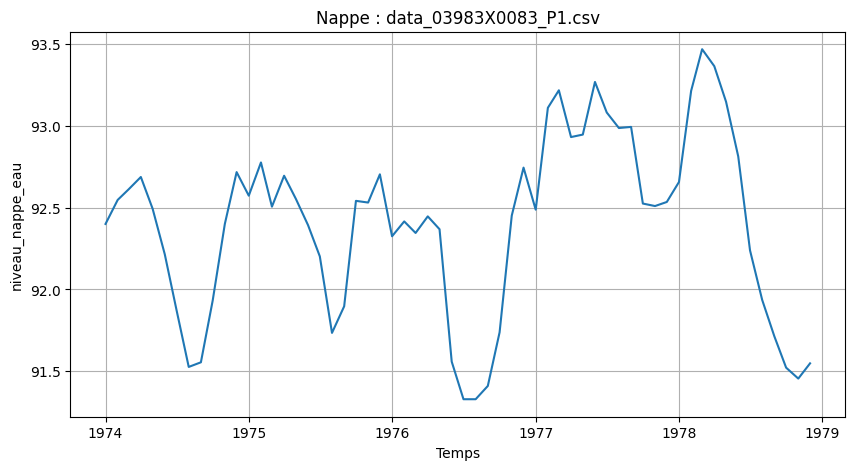

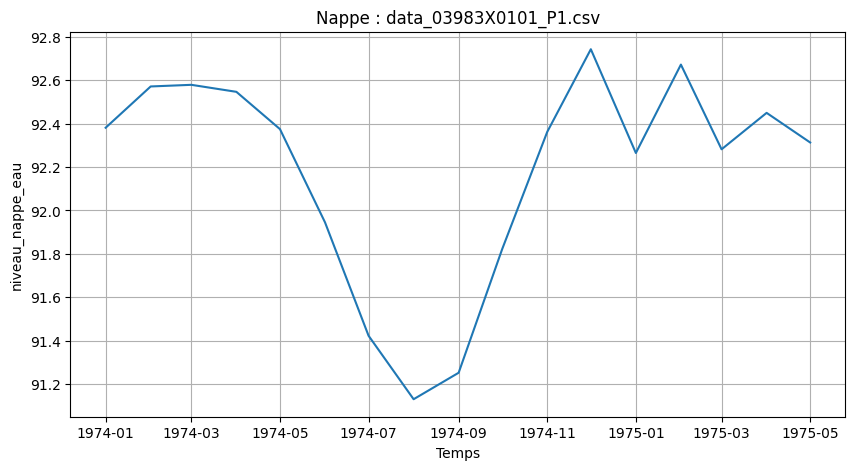

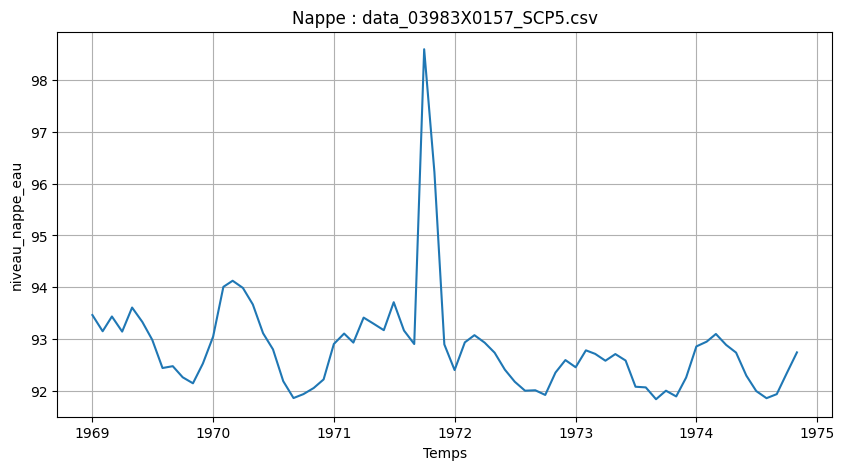

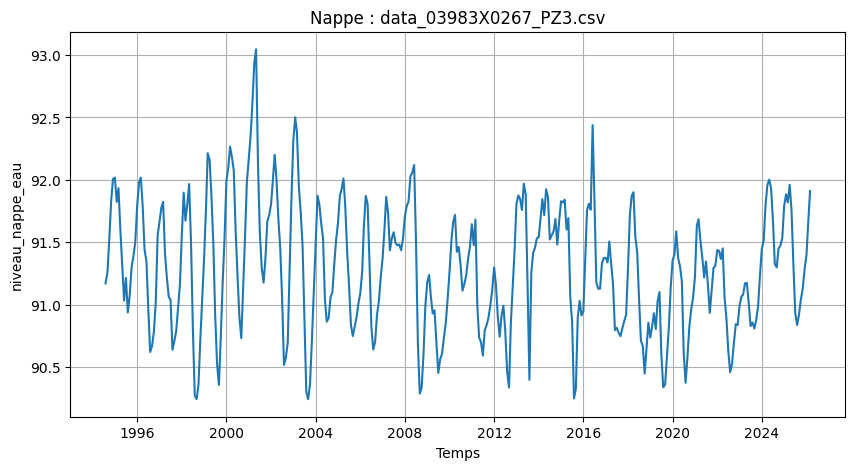

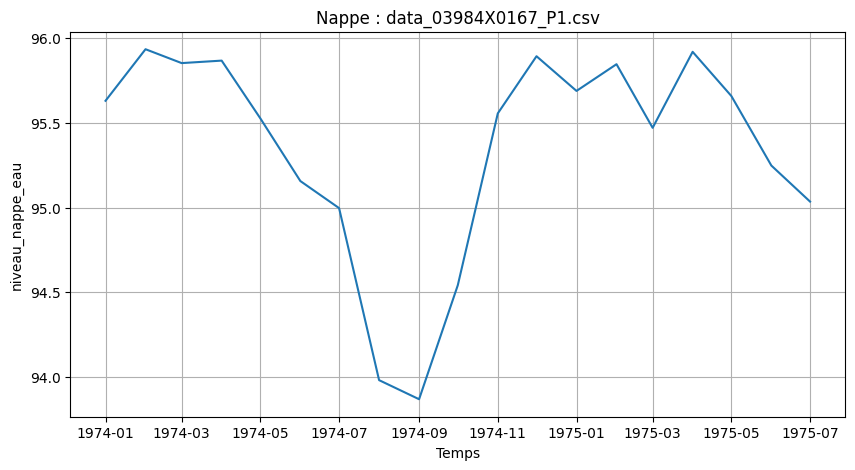

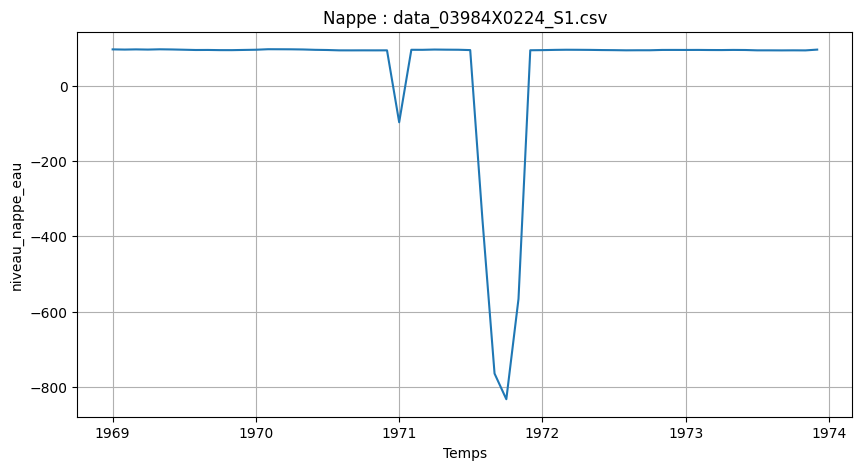

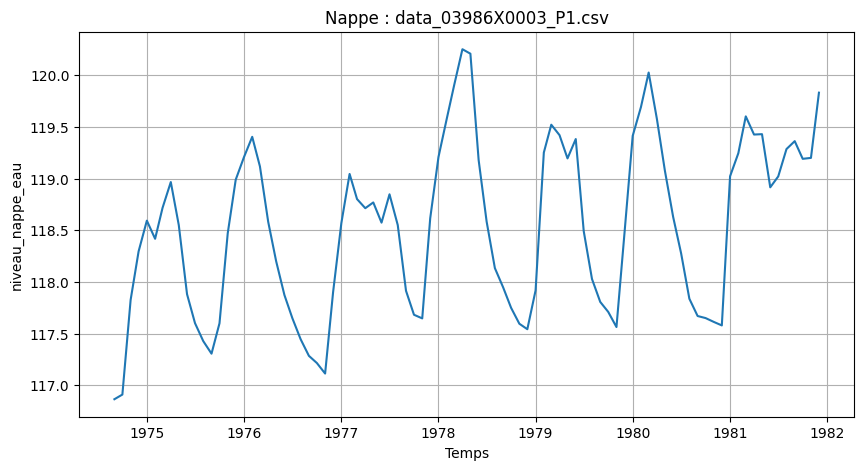

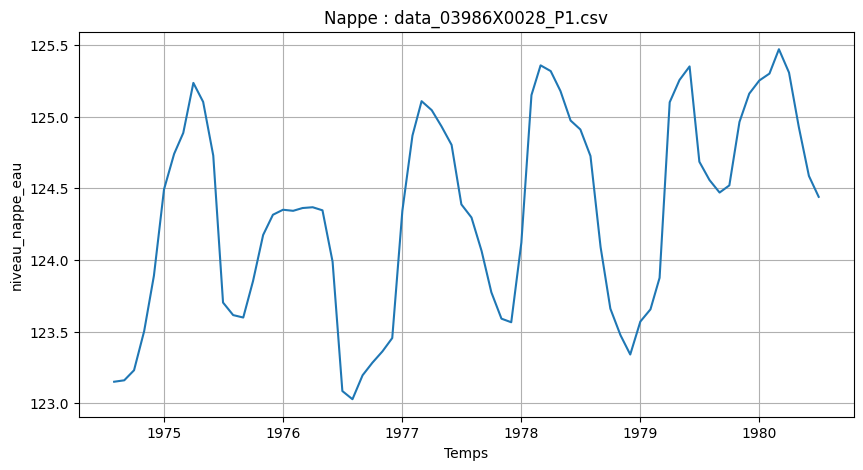

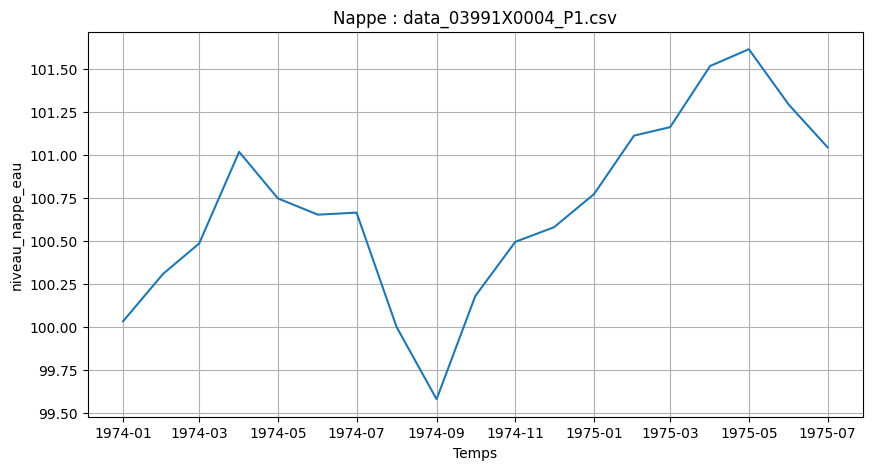

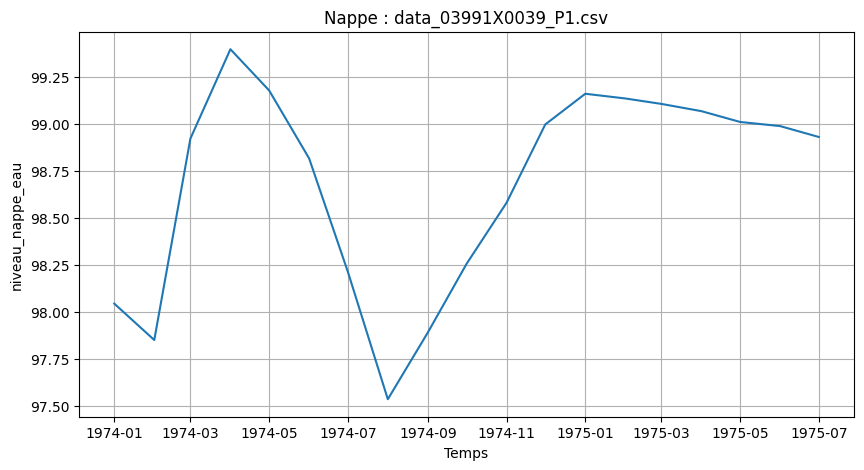

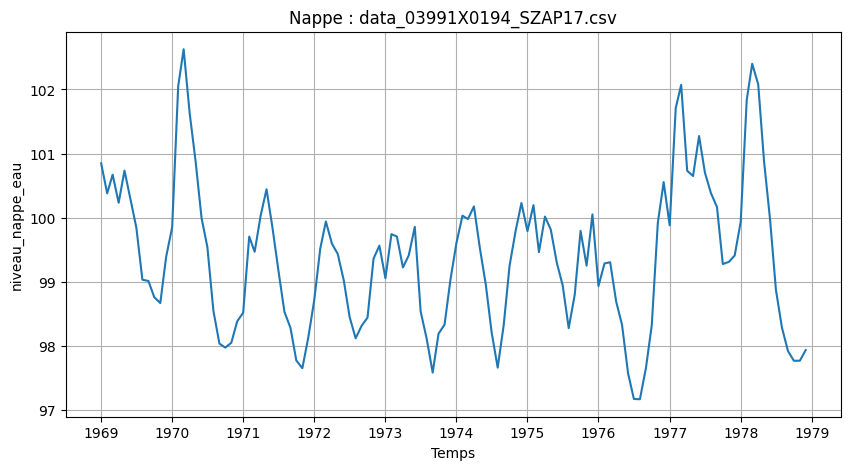

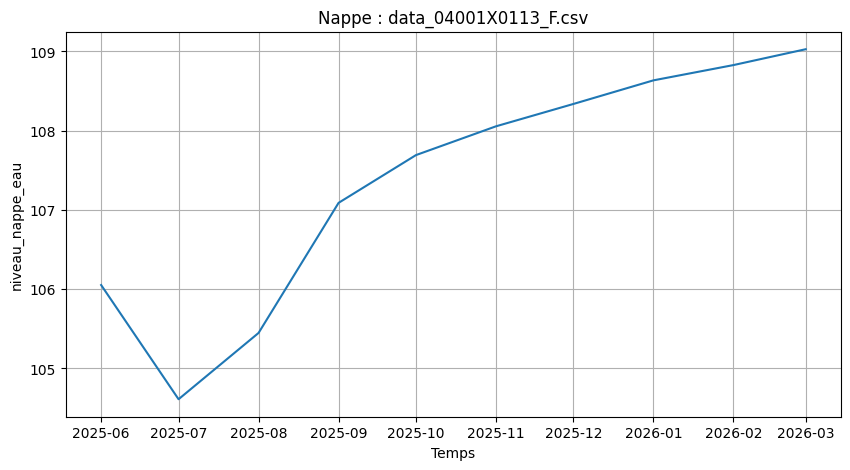

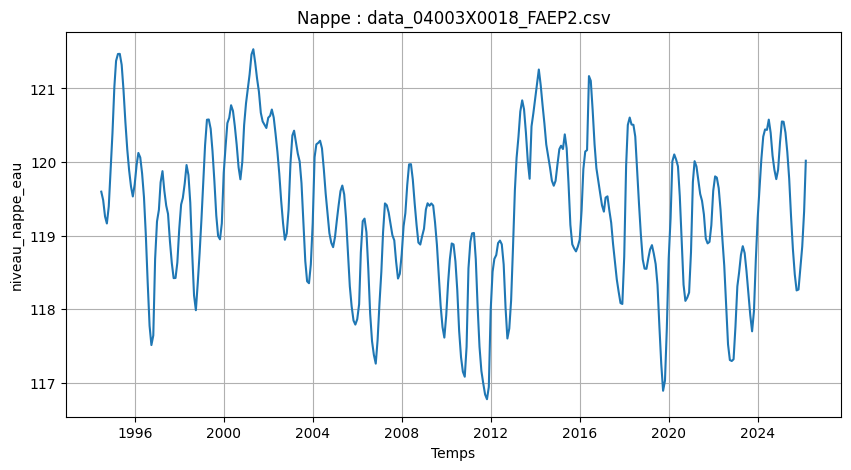

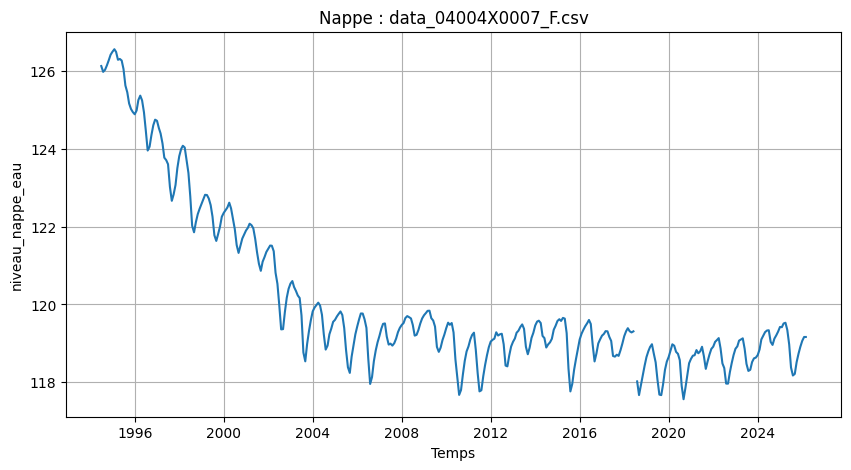

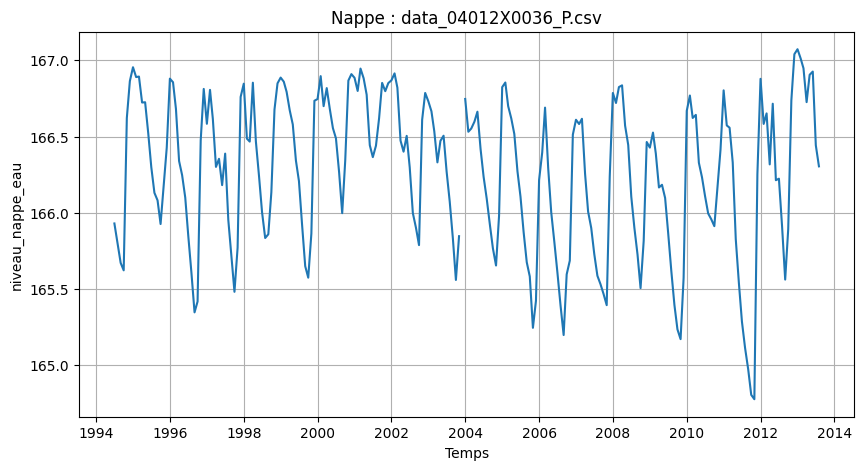

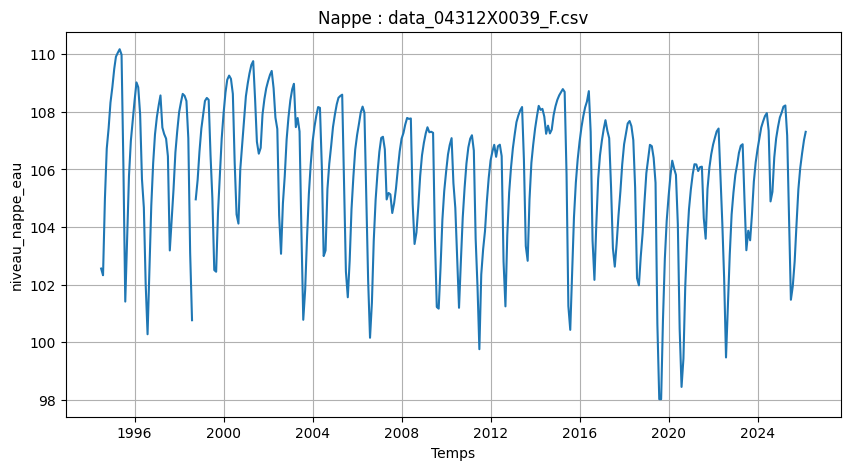

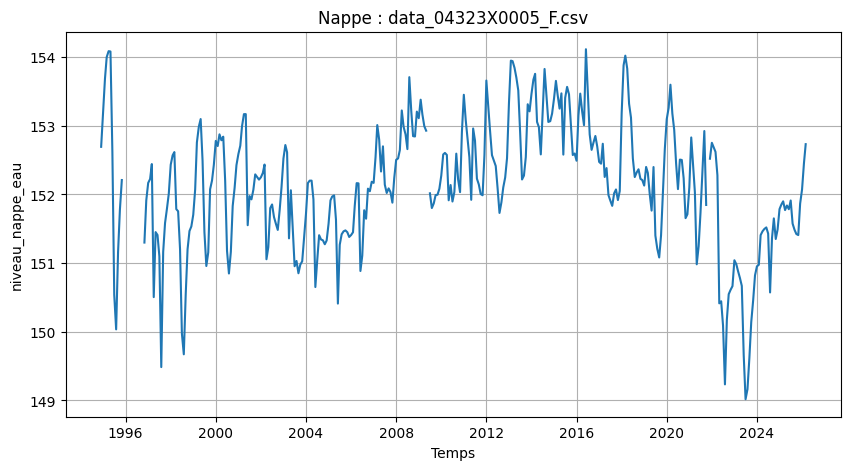

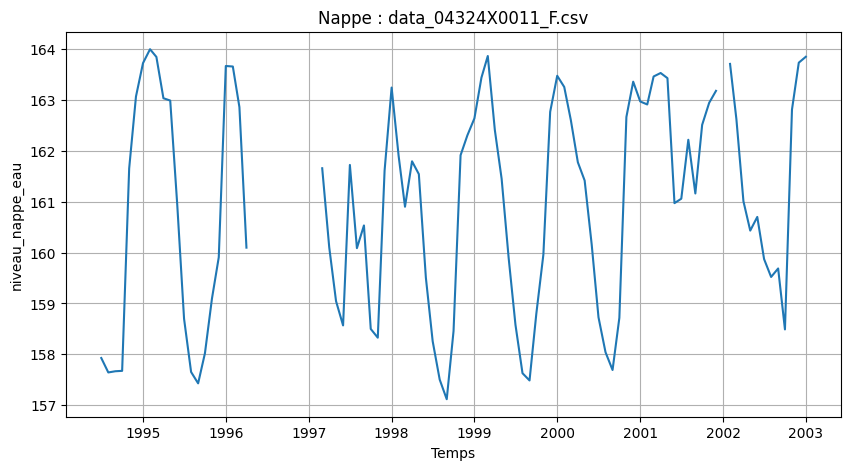

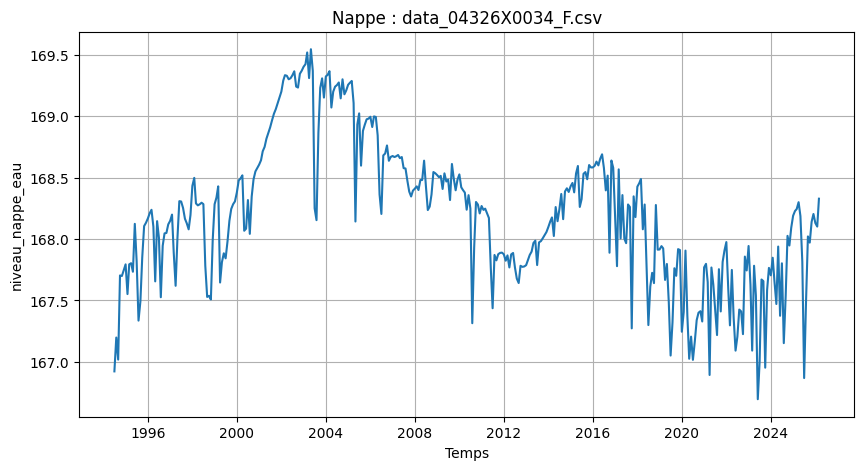

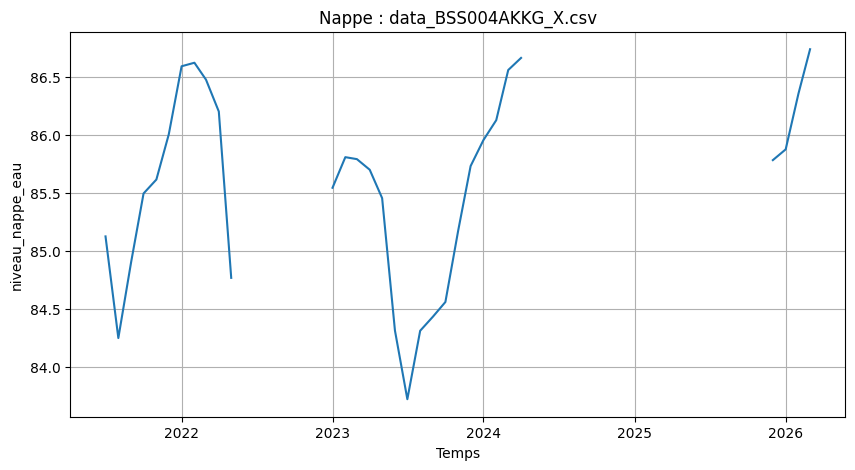

In [3]:
plot_nappes(dossier_nappe_reactive, "niveau_nappe_eau")